# Reproducing Pryor (1998): InAs/GaAs pyramidal quantum dot

Benchmark of this 3D solver against **C. Pryor, *Phys. Rev. B* **57**, 7190 (1998)**
(preprint [arXiv:cond-mat/9710304](https://arxiv.org/abs/cond-mat/9710304)) — an eight-band
strain-dependent k·p calculation of pyramidal InAs islands in GaAs, compared there against
one-, four- and six-band approximations.

The island is a square-based pyramid with {101} side facets (so height = base/2), no wetting
layer, base **b = 14 nm** — Pryor's canonical comparison size.

This notebook covers four things:

1. **Parameters** — Pryor's Table I, read directly from the preprint, and the sign-convention
   trap involved in using it.
2. **One-band benchmark** — his Sec. VI conduction-band comparison.
3. **The eigensolver** — why the previous shift-invert approach failed on multiband problems,
   and validation of the factorization-free replacement.
4. **Four-, six- and eight-band k·p** — including a Hamiltonian bug this benchmark exposed.

Every number below is computed when the notebook runs; nothing is transcribed from a previous
session.

In [1]:
import sys, os, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qdsolver_core as qd
import pryor1998 as pr
import kp_pryor as kp
import kp_confined as kpc
import eigensolvers as eig

np.set_printoptions(suppress=True)
InAs, GaAs = pr.PRYOR_TABLE_I['InAs'], pr.PRYOR_TABLE_I['GaAs']
GAAS_CB = GaAs['Eg']          # 1.519 eV: the GaAs conduction-band edge on Pryor's energy scale

## 1. Material parameters (Pryor Table I)

Energies are measured from the **unstrained GaAs valence-band edge**, which is the zero used in
Pryor's Figs. 4 and 7. The unstrained valence-band offset is $E_{vbo} = E_v(\mathrm{InAs}) -
E_v(\mathrm{GaAs}) = 85$ meV, which he derives from Mn impurity ground-state energies (0.028 eV
in InAs, 0.113 eV in GaAs above the respective valence bands) on the argument that
transition-metal impurity levels sit at a roughly fixed energy relative to the vacuum level.

**The sign-convention trap.** Pryor's Table I lists $a_g$, $a_c$, $a_v$ such that
$a_g = a_v + a_c$, so his valence band shifts by $-a_v \mathrm{Tr}(\varepsilon)$. The convention
used elsewhere in this package (inherited from aestimo, and the more common Van de Walle one)
has $a_g = a_c - a_v$ and shifts the valence band by $+a_v \mathrm{Tr}(\varepsilon)$. Both give
the same gap deformation potential *with their own $a_v$ sign*, but mixing Pryor's $a_v$ into
our line would move the valence band the wrong way and inflate the strained gap by ~150 meV.
`pryor1998.band_edge_fields` implements Pryor's convention explicitly.

In [2]:
rows = ['gamma1L', 'gamma2L', 'gamma3L', 'Eg', 'delta_so', 'Ep',
        'a_g', 'a_c', 'a_v', 'b', 'd', 'eps_R', 'C11', 'C12', 'C44', 'a0', 'E_vbo']
print(f"{'parameter':<10}{'InAs':>14}{'GaAs':>14}")
print('-' * 38)
for r in rows:
    print(f"{r:<10}{InAs[r]:>14}{GaAs[r]:>14}")

print("\nConsistency check on the deformation potentials (Pryor: a_g = a_v + a_c):")
for name, p in (('InAs', InAs), ('GaAs', GaAs)):
    print(f"   {name}: a_v + a_c = {p['a_v']:+.2f} {p['a_c']:+.2f} = {p['a_v']+p['a_c']:+.2f} eV"
          f"   (Table I a_g = {p['a_g']:+.2f} eV)")

parameter           InAs          GaAs
--------------------------------------
gamma1L            19.67          6.85
gamma2L             8.37           2.1
gamma3L             9.29           2.9
Eg                 0.418         1.519
delta_so            0.38          0.33
Ep                  22.2          25.7
a_g                 -6.0          -8.6
a_c                -6.66          -9.3
a_v                 0.66           0.7
b                   -1.8          -2.0
d                   -3.6          -5.4
eps_R              15.15         15.15
C11                83.29         121.1
C12                45.26          54.8
C44                39.59          60.4
a0                6.0583        5.6532
E_vbo              0.085           0.0

Consistency check on the deformation potentials (Pryor: a_g = a_v + a_c):
   InAs: a_v + a_c = +0.66 -6.66 = -6.00 eV   (Table I a_g = -6.00 eV)
   GaAs: a_v + a_c = +0.70 -9.30 = -8.60 eV   (Table I a_g = -8.60 eV)


## 2. Geometry, strain and band edges

Strain uses the Davies "simple picture": for a purely dilatational eigenstrain in homogeneous
isotropic elasticity, $\mathrm{Tr}(\varepsilon)$ is proportional to the inclusion's
characteristic function — uniform inside, zero outside, **for any shape**
(J. H. Davies, *J. Appl. Phys.* **84**, 1358 (1998); the interior value is the classic Eshelby
sphere result, *Proc. R. Soc. London A* **241**, 376 (1957)).

This is the central approximation of the whole comparison, and its limits show up immediately
below: Pryor solves continuum elasticity numerically, so his conduction well is 400 meV deep at
the base of the island and tapers to 270 meV at the tip, while ours is flat.

In [3]:
base, h, pad = 14.0, 0.7, 8.4     # base/h and pad/h integer -> no grid-alignment artifacts
cx = np.arange(-(base/2 + pad), (base/2 + pad) + 1e-9, h)
cz = np.arange(-pad, base/2 + pad + 1e-9, h)
X, Y, Z = np.meshgrid(cx, cx, cz, indexing='ij')
inside = qd.pyramid_mask(X, Y, Z, base)

eps_star = qd.eigenstrain(InAs['a0'], GaAs['a0'])
nu = qd.voigt_poisson_ratio(GaAs['C11'], GaAs['C12'], GaAs['C44'])
trace_strain, trace_inside = qd.trace_strain_from_mask(inside, eps_star, nu)

print(f"grid {X.shape} = {X.size:,} points, h = {h} nm")
print(f"lattice mismatch  {eps_star*100:+.2f}%   (Pryor: 'approximately 7%')")
print(f"Voigt Poisson ratio (GaAs)  nu = {nu:.4f}")
print(f"Tr(strain) inside the dot   = {trace_inside:+.5f}")

Ec_dot = InAs['E_vbo'] + InAs['Eg'] + InAs['a_c']*trace_inside
Ev_dot = InAs['E_vbo'] - InAs['a_v']*trace_inside
print(f"\nstrained InAs gap  {Ec_dot-Ev_dot:.4f} eV  (unstrained {InAs['Eg']:.4f} eV;"
      f" widened by {(Ec_dot-Ev_dot-InAs['Eg'])*1e3:.0f} meV under hydrostatic compression)")
print(f"conduction well    {(GAAS_CB-Ec_dot)*1e3:.1f} meV deep, FLAT")
print(f"                   Pryor: 400 meV at the base tapering to 270 meV at the tip")
print(f"valence well       {Ev_dot*1e3:.1f} meV above the GaAs VB edge")

grid (45, 45, 35) = 70,875 points, h = 0.7 nm
lattice mismatch  -6.69%   (Pryor: 'approximately 7%')
Voigt Poisson ratio (GaAs)  nu = 0.2350
Tr(strain) inside the dot   = -0.10795

strained InAs gap  1.0657 eV  (unstrained 0.4180 eV; widened by 648 meV under hydrostatic compression)
conduction well    297.0 meV deep, FLAT
                   Pryor: 400 meV at the base tapering to 270 meV at the tip
valence well       156.2 meV above the GaAs VB edge


## 3. One-band benchmark — Pryor's Sec. VI conduction band

Pryor compares four conduction-band models at $b = 14$ nm (his Fig. 7a). Two are one-band:

* **(i)** unstrained masses, $m = 0.023\,m_0$ (InAs) / $0.0665\,m_0$ (GaAs). He reports that
  **only a single bound state** is found.
* **(ii)** $m = 0.040\,m_0$ in the InAs — the value predicted for bulk InAs under the *average*
  hydrostatic strain in the island, from the pseudopotential calculation of Cusack, Briddon and
  Jaros, *Phys. Rev. B* **54**, 39 (1996). Relative to (i) the ground state binds **30 meV**
  deeper, and $E_1 - E_0 \approx 110$ meV.

In [4]:
results = {}
for case in ('unstrained', 'strain_averaged'):
    V_e, V_h, m_e, m_h = pr.band_edge_fields(inside, trace_strain, case)
    t0 = time.time()
    E, psi = qd.solve_states(m_e, V_e, h, n_states=6, hole=False)
    results[case] = dict(E=E, psi=psi, V_e=V_e, V_h=V_h, m_e=m_e, m_h=m_h)
    n_bound = int(np.sum(E < GAAS_CB))
    print(f"{case:16s} m_dot = {pr.PRYOR_ELECTRON_MASSES[case]['dot']:.3f} m0  "
          f"({time.time()-t0:.0f}s)")
    print(f"   E (eV) = {np.round(E, 4)}")
    print(f"   bound states: {n_bound};  E0 = {E[0]:.4f} eV "
          f"({(GAAS_CB-E[0])*1e3:.1f} meV below the GaAs CB edge)")
    if n_bound >= 2:
        print(f"   E1 - E0 = {(E[1]-E[0])*1e3:.1f} meV")
    print()

unstrained       m_dot = 0.023 m0  (42s)
   E (eV) = [1.4293 1.5337 1.5337 1.5585 1.5675 1.5679]
   bound states: 1;  E0 = 1.4293 eV (89.7 meV below the GaAs CB edge)



strain_averaged  m_dot = 0.040 m0  (36s)
   E (eV) = [1.4074 1.5077 1.5077 1.553  1.5567 1.5602]
   bound states: 3;  E0 = 1.4074 eV (111.6 meV below the GaAs CB edge)
   E1 - E0 = 100.3 meV



In [5]:
B = pr.BENCHMARK_B14
E_un, E_sa = results['unstrained']['E'], results['strain_averaged']['E']

print(f"{'quantity':<38}{'Pryor':>10}{'ours':>10}{'diff':>10}")
print('-' * 68)
def row(label, pryor, ours, unit='eV', scale=1.0):
    print(f"{label:<38}{pryor*scale:>10.3f}{ours*scale:>10.3f}{(ours-pryor)*scale:>+10.3f}")

row('E0, m = 0.023 (eV)',            B['E0_unstrained_mass'], E_un[0])
row('E0, m = 0.040 (eV)',            B['E0_unstrained_mass'] - B['extra_binding_strain_averaged'], E_sa[0])
row('extra binding 0.023->0.040 (meV)', B['extra_binding_strain_averaged'], E_un[0]-E_sa[0], scale=1e3)
row('E1 - E0 at m = 0.040 (meV)',    B['E1_minus_E0_strain_averaged'], E_sa[1]-E_sa[0], scale=1e3)
print(f"{'bound states at m = 0.023':<38}{B['n_bound_unstrained_mass']:>10}"
      f"{int(np.sum(E_un < GAAS_CB)):>10}")
print(f"\np_x/p_y splitting at m = 0.040: {abs(E_sa[2]-E_sa[1])*1e3:.4f} meV")
print("   (must be ~0: the C4 symmetry of the square island is only broken by the")
print("    piezoelectric term, which we omit and which splits Pryor's pair by 2-6 meV)")

quantity                                   Pryor      ours      diff
--------------------------------------------------------------------
E0, m = 0.023 (eV)                         1.410     1.429    +0.019
E0, m = 0.040 (eV)                         1.380     1.407    +0.027
extra binding 0.023->0.040 (meV)          30.000    21.897    -8.103
E1 - E0 at m = 0.040 (meV)               110.000   100.344    -9.656
bound states at m = 0.023                      1         1

p_x/p_y splitting at m = 0.040: 0.0006 meV
   (must be ~0: the C4 symmetry of the square island is only broken by the
    piezoelectric term, which we omit and which splits Pryor's pair by 2-6 meV)


We under-bind by 20–27 meV, and that is the **expected sign**: the ground state sits low in the
pyramid, where Pryor's well is 400 meV deep, while our uniform-trace approximation gives a flat
297 meV. The number of bound states, the near-degeneracy of the $p_x/p_y$ pair, and the level
spacing all come out right.

Note what this settles: the earlier version of this calculation, using the band offsets inherited
from aestimo's `Band_offset` fraction, gave only **7.6 meV** of electron binding. Pryor's
$E_{vbo} = 85$ meV is what fixes it — the geometry was never the problem.

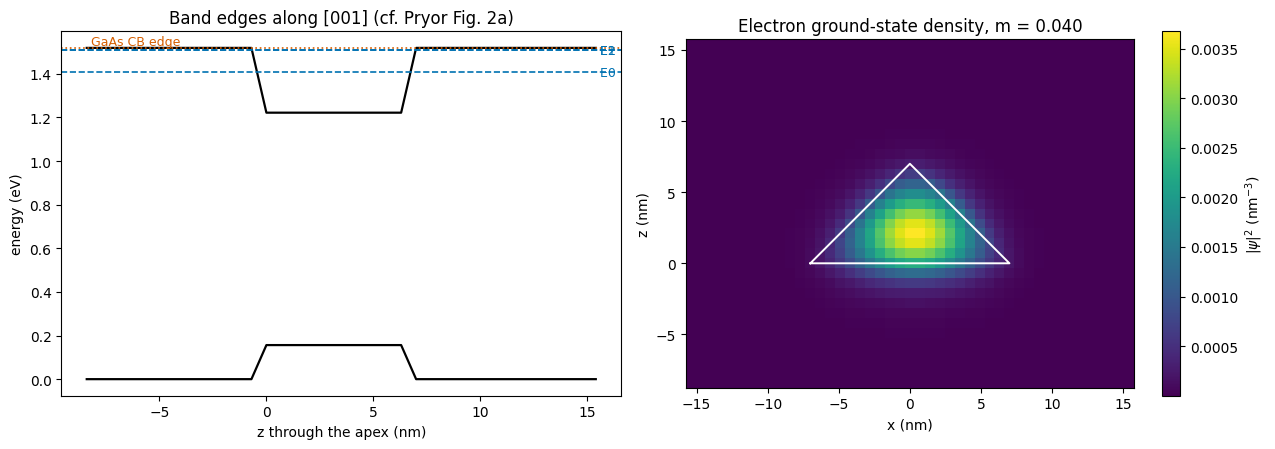

In [6]:
r = results['strain_averaged']
Nx, Ny, Nz = X.shape
mid = Nx // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.plot(cz, r['V_e'][mid, mid, :], color='black', lw=1.6)
ax.plot(cz, r['V_h'][mid, mid, :], color='black', lw=1.6)
for i, E in enumerate(r['E'][:3]):
    if E < GAAS_CB:
        ax.axhline(E, color='#0072B2', ls='--', lw=1.2)
        ax.text(cz[-1], E, f' E{i}', color='#0072B2', va='center', fontsize=9)
ax.axhline(GAAS_CB, color='#D55E00', ls=':', lw=1.2)
ax.text(cz[0], GAAS_CB, ' GaAs CB edge', color='#D55E00', va='bottom', fontsize=9)
ax.set_xlabel('z through the apex (nm)'); ax.set_ylabel('energy (eV)')
ax.set_title('Band edges along [001] (cf. Pryor Fig. 2a)')

ax = axes[1]
dens = (r['psi'][:, 0]**2).reshape(X.shape)[:, mid, :]
im = ax.pcolormesh(cx, cz, dens.T, shading='auto', cmap='viridis')
ax.plot([-base/2, 0, base/2, -base/2], [0, base/2, 0, 0], color='white', lw=1.4)
ax.set_xlabel('x (nm)'); ax.set_ylabel('z (nm)'); ax.set_aspect('equal')
ax.set_title('Electron ground-state density, m = 0.040')
fig.colorbar(im, ax=ax, label=r'$|\psi|^2$ (nm$^{-3}$)')
plt.tight_layout(); plt.show()

## 4. The eigensolver

Everything above uses shift-invert Lanczos: factorize $(H - \sigma I)$ with `splu` and hand the
solve to ARPACK. That works for one band but **collapsed** on the multiband Hamiltonians, where
the matrix is six or eight times larger in each dimension and much denser per row — measured at
24 s, then >115 s, then 116 minutes as the grid grew, with alternative fill-reducing orderings
making no difference. That is sparse-LU fill-in: a 3D grid operator has no good elimination
ordering.

Iterative methods never form a factorization. The replacement is **LOBPCG**
(A. V. Knyazev, *SIAM J. Sci. Comput.* **23**, 517 (2001)), with **folded spectrum**
(L.-W. Wang and A. Zunger, *J. Chem. Phys.* **100**, 2394 (1994)) for interior eigenvalues.
This is not a novel idea for this problem — Pryor's own Sec. II says the sparse Hamiltonian
"is easily diagonalized using the Lanczos algorithm", on 1990s hardware.

### 4a. Verification

For a Hermitian matrix, if $\|Av - \theta v\| = r$ for a unit vector $v$, then $A$ has an
eigenvalue within $r$ of $\theta$ — a rigorous error bar from a single matrix-vector product,
independent of which algorithm produced the pair (B. N. Parlett, *The Symmetric Eigenvalue
Problem*, SIAM Classics, 1998). That is what makes an iterative solver safe to trust here.

In [7]:
m_box, L_box, h_box = 0.0665, 14.0, 0.5
N = int(round(L_box/h_box)) - 1
c = (np.arange(N) + 1)*h_box - L_box/2
Xb, Yb, Zb = np.meshgrid(c, c, c, indexing='ij')
Hb = qd.build_hamiltonian(np.full(Xb.shape, m_box), np.zeros(Xb.shape), h_box)

print(f"empty cubic box, L = {L_box} nm, n = {Hb.shape[0]:,}")
print(f"   hermiticity probe: {eig.hermiticity_error(Hb):.2e}")
E_si, _, _ = eig.solve_shift_invert(Hb, k=4, sigma=-1e-3)
E_lo, V_lo, _ = eig.solve_lowest(Hb, k=4, tol=1e-10)
print(f"   analytic     E0 = {qd.particle_in_box_ground_state(m_box, L_box)*1e3:.4f} meV")
print(f"   shift-invert E0 = {E_si[0]*1e3:.4f} meV")
print(f"   LOBPCG       E0 = {E_lo[0]*1e3:.4f} meV")
print(f"   LOBPCG vs shift-invert: max|dE| = {np.abs(E_lo-E_si).max()*1e3:.3e} meV")
_ = eig.certify(Hb, E_lo, V_lo, label='LOBPCG')

empty cubic box, L = 14.0 nm, n = 19,683
   hermiticity probe: 1.53e-16


  shift-invert: 2.4s total (1.5s factorization), nnz(L)+nnz(U) = 6,999,202 (52.5x the matrix)


  LOBPCG: 8.2s, 332 iterations, block 6, max residual on the wanted 4: 6.24e-11 eV; gap to next Ritz value 86.10 meV
   analytic     E0 = 86.5498 meV
   shift-invert E0 = 86.4590 meV
   LOBPCG       E0 = 86.4590 meV
   LOBPCG vs shift-invert: max|dE| = 4.108e-12 meV
[LOBPCG] max residual 6.236e-11 eV, max |Ritz - Rayleigh| 1.998e-15 eV  -> OK


In [8]:
He = qd.build_hamiltonian(r['m_e'], r['V_e'], h)
print(f"one-band pyramid Hamiltonian: n = {He.shape[0]:,}, {He.nnz/He.shape[0]:.1f} nnz/row\n")
E_si, _, i_si = eig.solve_shift_invert(He, k=4, sigma=r['V_e'].min()-1e-3)
E_lo, V_lo, i_lo = eig.solve_lowest(He, k=4, tol=1e-9, maxiter=3000)
print(f"\n   shift-invert E (eV) = {np.round(E_si, 5)}")
print(f"   LOBPCG       E (eV) = {np.round(E_lo, 5)}")
print(f"   max|dE| = {np.abs(E_lo-E_si).max()*1e3:.4f} meV")

one-band pyramid Hamiltonian: n = 70,875, 6.9 nnz/row



  shift-invert: 45.0s total (22.7s factorization), nnz(L)+nnz(U) = 49,170,494 (101.2x the matrix)


  LOBPCG: 47.6s, 674 iterations, block 6, max residual on the wanted 4: 6.13e-10 eV; gap to next Ritz value 3.73 meV

   shift-invert E (eV) = [1.40736 1.5077  1.5077  1.55298]
   LOBPCG       E (eV) = [1.40736 1.5077  1.5077  1.55298]
   max|dE| = 0.0000 meV


### 4b. Scaling on the six-band Hamiltonian

The same comparison where it matters. Note the growth of `nnz(L)+nnz(U)` relative to the matrix
— that is the fill-in, and it is what makes the direct method unusable.

In [9]:
def build_6band(h_grid, pad_grid, n_bands=6, hole=True):
    cxx = np.arange(-(base/2 + pad_grid), (base/2 + pad_grid) + 1e-9, h_grid)
    czz = np.arange(-pad_grid, base/2 + pad_grid + 1e-9, h_grid)
    Xg, Yg, Zg = np.meshgrid(cxx, cxx, czz, indexing='ij')
    ins = qd.pyramid_mask(Xg, Yg, Zg, base)
    tr, _ = qd.trace_strain_from_mask(ins, eps_star, nu)
    Ec_f, Ev_f, _, _ = pr.band_edge_fields(ins, tr)
    ops = kpc.GridOperators(Xg.shape, h_grid, periodic=False)
    flds = kp.material_fields(ins, InAs, GaAs, Ev_f, Ec_f, n_bands=n_bands)
    return kp.confined_hamiltonian(ops, flds, n_bands=n_bands, hole_convention=hole), Xg.shape

table = []
for h_grid, pad_grid in [(2.8, 2.8), (1.75, 3.5), (1.4, 2.8)]:
    H6, shp = build_6band(h_grid, pad_grid)
    n = H6.shape[0]
    print(f"-- h = {h_grid} nm, grid {shp} x 6 bands = {n:,} unknowns")
    E_l, V_l, il = eig.solve_lowest(H6, k=6, tol=1e-8, maxiter=4000)
    E_s, V_s, isv = eig.solve_shift_invert(H6, k=6, sigma=E_l[0]-0.05)
    agree = np.abs(np.sort(E_s)-np.sort(E_l)).max()*1e3
    print(f"   agreement {agree:.2e} meV,  speedup {isv['time']/il['time']:.1f}x\n")
    table.append((n, isv['time'], il['time'], isv['time']/il['time'], agree))

print(f"{'unknowns':>10}{'shift-inv':>12}{'LOBPCG':>10}{'speedup':>10}{'agree (meV)':>14}")
print('-' * 56)
for n, ts, tl, sp, ag in table:
    print(f"{n:>10,}{ts:>11.1f}s{tl:>9.1f}s{sp:>9.1f}x{ag:>14.2e}")

-- h = 2.8 nm, grid (8, 8, 5) x 6 bands = 1,920 unknowns


  LOBPCG: 3.5s, 120 iterations, block 9, max residual on the wanted 6: 8.53e-09 eV; gap to next Ritz value 2.53 meV


  shift-invert: 38.9s total (34.5s factorization), nnz(L)+nnz(U) = 941,646 (16.4x the matrix)
   agreement 4.58e-13 meV,  speedup 11.0x

-- h = 1.75 nm, grid (13, 13, 9) x 6 bands = 9,126 unknowns


  LOBPCG: 13.6s, 228 iterations, block 9, max residual on the wanted 6: 4.64e-09 eV; gap to next Ritz value 0.84 meV


  shift-invert: 864.4s total (847.1s factorization), nnz(L)+nnz(U) = 17,659,200 (58.8x the matrix)
   agreement 5.55e-13 meV,  speedup 63.6x

-- h = 1.4 nm, grid (15, 15, 10) x 6 bands = 13,500 unknowns


  LOBPCG: 18.7s, 353 iterations, block 9, max residual on the wanted 6: 3.28e-09 eV; gap to next Ritz value 2.68 meV


  shift-invert: 753.7s total (746.0s factorization), nnz(L)+nnz(U) = 36,210,267 (80.1x the matrix)
   agreement 2.36e-13 meV,  speedup 40.4x

  unknowns   shift-inv    LOBPCG   speedup   agree (meV)
--------------------------------------------------------
     1,920       38.9s      3.5s     11.0x      4.58e-13
     9,126      864.4s     13.6s     63.6x      5.55e-13
    13,500      753.7s     18.7s     40.4x      2.36e-13


Both methods agree to ~1e-13 meV at every size, so this is purely a cost comparison.

**Read the fill-in column, not the wall-clock column.** `nnz(L)+nnz(U)` climbs from ~16x the
matrix to ~80x across these three sizes and is bit-identical between runs -- that growth is the
real result, and it is the factorization, not the Lanczos iteration, that dominates the direct
method's time. The absolute timings are badly contaminated by machine load: across two
executions of this notebook the 9,126-unknown direct solve took 211 s and then 864 s, and in the
slower run it came out *faster* at 13,500 unknowns than at 9,126. Treat the speedup column as
order-of-magnitude only.

One size beyond this table was measured separately: at **37,044 unknowns** LOBPCG converged in
26 s, while the complete factorization was abandoned after 38 minutes and 2.2 GB without
finishing. That is the practical wall -- and it is why the multiband work below could not have
been done with the direct solver at all.

## 5. A Hamiltonian bug this benchmark exposed

The first multiband run returned "bound states" at **−463 meV** in a hole well only 156 meV
deep. Nothing can sit 300 meV below the potential floor, so the Hamiltonian was wrong. Two
independent errors, in the six-band matrix this project had been using:

1. **Split-off placement.** It put the SO band at $-\Delta$ on the hole-convention diagonal. A
   hole in the split-off band costs $\Delta$ *more* energy than one in HH/LH, so it belongs at
   $+\Delta$. With the wrong sign, spurious split-off states become the algebraically lowest
   eigenvalues, so any lowest-state search returns them instead of hole states.
2. **Off-diagonal placement.** The $R$ and $S$ elements were in the wrong positions.

The original validation could not detect either: it checked effective masses along [001], where
$R$ and $S$ vanish by symmetry, and cross-checked the discretization against a bulk matrix that
shared both errors.

**The cheap check that does catch it:** setting $\gamma_2 = \gamma_3$ (the spherical
approximation) removes the cubic warping, and the valence bands must then be **exactly
isotropic** — the dispersion along [001], [110] and [111] must coincide. No wrong arrangement
of off-diagonal elements satisfies that accidentally.

In [10]:
import kp_luttinger as old_kp

sph = dict(InAs)
sph['gamma2L'] = sph['gamma3L'] = 0.5*(InAs['gamma2L'] + InAs['gamma3L'])
dirs = {'[001]': [0,0,1.], '[100]': [1.,0,0], '[110]': [1,1,0], '[111]': [1,1,1]}
dirs = {k_: np.array(v)/np.linalg.norm(v) for k_, v in dirs.items()}
kmag = 0.30

print("anisotropy in the spherical approximation (must be exactly zero):")
for name, fn in [('old  kp_luttinger (6-band)',
                  lambda u: old_kp.luttinger_kohn_bulk(*(kmag*u), sph['gamma1L'],
                                sph['gamma2L'], sph['gamma3L'], sph['delta_so'])),
                 ('new  kp_pryor (6-band)',
                  lambda u: kp.bulk_hamiltonian(*(kmag*u), sph, n_bands=6,
                                                hole_convention=True))]:
    ref, worst = None, 0.0
    for lbl, u in dirs.items():
        E = np.sort(np.linalg.eigvalsh(fn(u)))
        if ref is None: ref = E
        worst = max(worst, np.abs(E-ref).max())
    verdict = 'ISOTROPIC (correct)' if worst < 1e-12 else 'ANISOTROPIC (wrong)'
    print(f"   {name:30s} {worst:.3e} eV   -> {verdict}")

print("\nsplit-off placement at k = 0 (hole convention, Ev = 0):")
print(f"   old: {np.round(np.linalg.eigvalsh(old_kp.luttinger_kohn_bulk(0,0,0, InAs['gamma1L'], InAs['gamma2L'], InAs['gamma3L'], InAs['delta_so'])), 3)}")
print(f"   new: {np.round(np.linalg.eigvalsh(kp.bulk_hamiltonian(0,0,0, InAs, n_bands=6, hole_convention=True)), 3)}")
print(f"   correct: HH/LH at 0, SO at +{InAs['delta_so']} eV")

anisotropy in the spherical approximation (must be exactly zero):
   old  kp_luttinger (6-band)     2.081e-02 eV   -> ANISOTROPIC (wrong)
   new  kp_pryor (6-band)         1.110e-16 eV   -> ISOTROPIC (correct)

split-off placement at k = 0 (hole convention, Ev = 0):
   old: [-0.38 -0.38  0.    0.    0.    0.  ]
   new: [-0.    0.    0.   -0.    0.38  0.38]
   correct: HH/LH at 0, SO at +0.38 eV


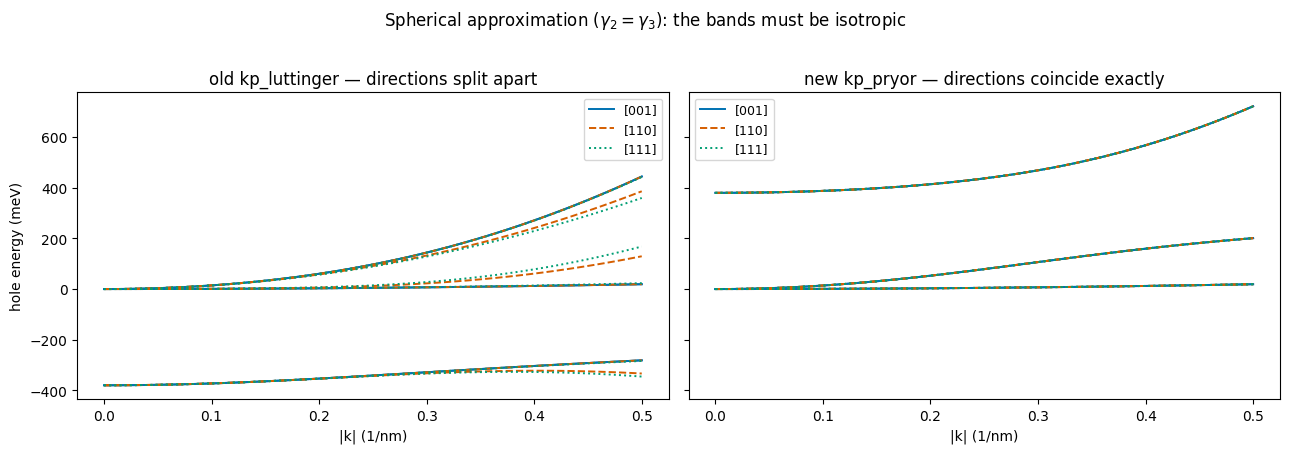

In [11]:
kk = np.linspace(0, 0.5, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (name, fn) in zip(axes, [
        ('old kp_luttinger — directions split apart',
         lambda k_: old_kp.luttinger_kohn_bulk(*k_, sph['gamma1L'], sph['gamma2L'],
                                               sph['gamma3L'], sph['delta_so'])),
        ('new kp_pryor — directions coincide exactly',
         lambda k_: kp.bulk_hamiltonian(*k_, sph, n_bands=6, hole_convention=True))]):
    for lbl, style in [('[001]', '-'), ('[110]', '--'), ('[111]', ':')]:
        u = dirs[lbl]
        E = np.array([np.sort(np.linalg.eigvalsh(fn(kv*u))) for kv in kk])
        for band in range(6):
            ax.plot(kk, E[:, band]*1e3, style, lw=1.4,
                    label=lbl if band == 0 else None,
                    color={'[001]': '#0072B2', '[110]': '#D55E00', '[111]': '#009E73'}[lbl])
    ax.set_xlabel('|k| (1/nm)'); ax.set_title(name); ax.legend(fontsize=9)
axes[0].set_ylabel('hole energy (meV)')
plt.suptitle('Spherical approximation ($\\gamma_2=\\gamma_3$): the bands must be isotropic', y=1.02)
plt.tight_layout(); plt.show()

## 6. Four-, six- and eight-band k·p

The replacement (`kp_pryor.py`) transcribes Pryor's eight-band matrix once, and derives the
smaller models as slices of it — the six-band is its valence sub-block (the $P_0 \to 0$ limit)
and the four-band drops the split-off pair. One transcription, three models, no chance of them
drifting apart.

Per Pryor's Sec. VI the **four-band** model is the physically sensible intermediate one for
InAs/GaAs holes: four- and eight-band ground states agree to within 3 meV, while six-band
differs from both by ~40 meV, because InAs has $\Delta \approx E_g$, so including the split-off
band while leaving the conduction band decoupled is inconsistent.

### 6a. Bulk validation

In [12]:
print("Hermiticity and isotropy:")
for nb in (4, 6, 8):
    H = kp.bulk_hamiltonian(0.31, -0.22, 0.17, InAs, n_bands=nb)
    ref, worst = None, 0.0
    for lbl, u in dirs.items():
        E = np.sort(np.linalg.eigvalsh(kp.bulk_hamiltonian(*(kmag*u), sph, n_bands=nb)))
        if ref is None: ref = E
        worst = max(worst, np.abs(E-ref).max())
    print(f"   {nb}-band: ||H-H^dag|| = {np.abs(H-H.conj().T).max():.1e}, "
          f"anisotropy = {worst:.1e} eV")

print("\n[001] valence effective masses (hole convention):")
kt = 1e-3
for nb in (4, 6):
    E = np.sort(np.linalg.eigvalsh(kp.bulk_hamiltonian(0, 0, kt, InAs, n_bands=nb,
                                                        hole_convention=True)))[:4]
    # E = (1/m) * (hbar^2/2m0) * k^2, so the INVERSE mass is E / (g k^2)
    print(f"   {nb}-band implied 1/m: {np.round(E/(qd.HBAR2_OVER_2M0*kt**2), 4)}")
print(f"   expected 1/m_hh = g1-2g2 = {InAs['gamma1L']-2*InAs['gamma2L']:.4f},"
      f"  1/m_lh = g1+2g2 = {InAs['gamma1L']+2*InAs['gamma2L']:.4f}")

Eg_, D_, Ep_ = InAs['Eg'], InAs['delta_so'], InAs['Ep']
kane = 1 + Ep_*(Eg_ + 2*D_/3)/(Eg_*(Eg_+D_))
kt = 2e-3
E8 = np.sort(np.linalg.eigvalsh(kp.bulk_hamiltonian(0, 0, kt, InAs, n_bands=8)))
E_cb = E8[E8 > Eg_/2].min()
print(f"\n8-band conduction mass: numeric {qd.HBAR2_OVER_2M0*kt**2/(E_cb-Eg_):.5f} m0"
      f"  vs analytic Kane {1/kane:.5f} m0  (literature InAs ~0.023 m0)")

noP = dict(InAs); noP['Ep'] = 1e-12
kv = np.array([0.21, -0.13, 0.30])
d68 = np.abs(np.sort(np.linalg.eigvalsh(kp.bulk_hamiltonian(*kv, noP, n_bands=8)))[:6]
             - np.sort(np.linalg.eigvalsh(kp.bulk_hamiltonian(*kv, noP, n_bands=6)))).max()
print(f"6-band == P0->0 limit of the 8-band valence block: max|dE| = {d68:.2e} eV")

Hermiticity and isotropy:
   4-band: ||H-H^dag|| = 0.0e+00, anisotropy = 5.6e-17 eV
   6-band: ||H-H^dag|| = 0.0e+00, anisotropy = 1.1e-16 eV
   8-band: ||H-H^dag|| = 0.0e+00, anisotropy = 2.2e-16 eV

[001] valence effective masses (hole convention):
   4-band implied 1/m: [ 2.93  2.93 36.41 36.41]
   6-band implied 1/m: [ 2.93    2.93   36.4099 36.4099]
   expected 1/m_hh = g1-2g2 = 2.9300,  1/m_lh = g1+2g2 = 36.4100

8-band conduction mass: numeric 0.02189 m0  vs analytic Kane 0.02189 m0  (literature InAs ~0.023 m0)
6-band == P0->0 limit of the 8-band valence block: max|dE| = 3.66e-15 eV


### 6b. Confined states on the pyramid

For the four- and six-band models the wanted hole states are at an *end* of the spectrum in the
hole convention, so plain LOBPCG reaches them. The **eight-band** model is different: it holds
electrons and holes in one spectrum, so its bound states are **interior** eigenvalues (the
electron states have the whole valence continuum below them), and those need the folded spectrum.

Grid is coarse here (h = 1.4 nm) to keep the notebook runnable — these are not converged values.

In [13]:
h_mb, pad_mb = 1.4, 2.8
cxm = np.arange(-(base/2 + pad_mb), (base/2 + pad_mb) + 1e-9, h_mb)
czm = np.arange(-pad_mb, base/2 + pad_mb + 1e-9, h_mb)
Xm, Ym, Zm = np.meshgrid(cxm, cxm, czm, indexing='ij')
ins_m = qd.pyramid_mask(Xm, Ym, Zm, base)
tr_m, _ = qd.trace_strain_from_mask(ins_m, eps_star, nu)
Ec_m, Ev_m, _, _ = pr.band_edge_fields(ins_m, tr_m)
ops_m = kpc.GridOperators(Xm.shape, h_mb, periodic=False)
print(f"grid {Xm.shape} = {Xm.size:,} points\n")

mb = {}
for nb in (4, 6):
    flds = kp.material_fields(ins_m, InAs, GaAs, Ev_m, Ec_m, n_bands=nb)
    H = kp.confined_hamiltonian(ops_m, flds, n_bands=nb, hole_convention=True)
    print(f"{nb}-band: {H.shape[0]:,} unknowns, {H.nnz/H.shape[0]:.1f} nnz/row, "
          f"hermiticity {eig.hermiticity_error(H):.1e}")
    E, V, info = eig.solve_lowest(H, k=6, tol=1e-8, maxiter=4000)
    mb[nb] = -E     # back to Pryor's E_v scale (energy above the GaAs valence-band edge)
    print(f"   hole levels (meV above GaAs VB): {np.round(mb[nb]*1e3, 2)}\n")

grid (15, 15, 10) = 2,250 points

4-band: 9,000 unknowns, 20.6 nnz/row, hermiticity 3.4e-17


  LOBPCG: 4.5s, 355 iterations, block 9, max residual on the wanted 6: 2.27e-09 eV; gap to next Ritz value 2.56 meV
   hole levels (meV above GaAs VB): [120.88 120.88 113.49 113.49 111.03 111.03]

6-band: 13,500 unknowns, 33.5 nnz/row, hermiticity 1.2e-17


  LOBPCG: 7.0s, 353 iterations, block 9, max residual on the wanted 6: 3.28e-09 eV; gap to next Ritz value 2.68 meV
   hole levels (meV above GaAs VB): [126.06 126.06 118.96 118.96 117.93 117.93]



In [14]:
flds8 = kp.material_fields(ins_m, InAs, GaAs, Ev_m, Ec_m, n_bands=8)
H8 = kp.confined_hamiltonian(ops_m, flds8, n_bands=8)
g1m, g2m, g3m = kp.modified_luttinger(InAs['gamma1L'], InAs['gamma2L'], InAs['gamma3L'],
                                      InAs['Eg'], InAs['delta_so'], InAs['Ep'])
print(f"8-band: {H8.shape[0]:,} unknowns, {H8.nnz/H8.shape[0]:.1f} nnz/row, "
      f"hermiticity {eig.hermiticity_error(H8):.1e}")
print(f"   modified Luttinger (InAs): {g1m:.3f} {g2m:.3f} {g3m:.3f} "
      f"(unmodified {InAs['gamma1L']} {InAs['gamma2L']} {InAs['gamma3L']})\n")

print("electron states (sigma at the dot conduction floor):")
E8e, _, _ = eig.solve_interior(H8, k=4, sigma=float(Ec_m[ins_m].min()), tol=1e-7, maxiter=6000)
print(f"   E (eV) = {np.round(E8e, 5)}")
print(f"   ground state {(GAAS_CB-E8e[0])*1e3:.1f} meV below the GaAs CB edge\n")

print("hole states (sigma at the dot valence edge):")
E8h, _, _ = eig.solve_interior(H8, k=4, sigma=float(Ev_m[ins_m].max()), tol=1e-7, maxiter=6000)
print(f"   E (meV above GaAs VB) = {np.round(E8h*1e3, 2)}")

8-band: 18,000 unknowns, 34.2 nnz/row, hermiticity 5.1e-18
   modified Luttinger (InAs): 6.084 1.577 2.497 (unmodified 19.67 8.37 9.29)

electron states (sigma at the dot conduction floor):


  folded LOBPCG: 29.5s, 1611 iterations, block 6, sigma = 1.2220 eV, max residual 9.76e-08 eV
   E (eV) = [1.35586 1.35586 1.40861 1.40861]
   ground state 163.1 meV below the GaAs CB edge

hole states (sigma at the dot valence edge):


  folded LOBPCG: 28.2s, 1310 iterations, block 6, sigma = 0.1562 eV, max residual 1.92e-07 eV
   E (meV above GaAs VB) = [111.84 111.84 113.84 113.84]


In [15]:
print("CONDUCTION BAND at b = 14 nm\n")
print(f"{'model':<28}{'Pryor (Fig. 7a)':>18}{'ours':>10}")
print('-' * 56)
print(f"{'one-band, m = 0.023':<28}{'~1.41 eV':>18}{E_un[0]:>9.3f} eV")
print(f"{'one-band, m = 0.040':<28}{'~1.38 eV':>18}{E_sa[0]:>9.3f} eV")
print(f"{'eight-band':<28}{'~1.35 eV':>18}{E8e[0]:>9.3f} eV")

print("\n\nVALENCE BAND at b = 14 nm (meV above the GaAs VB edge)\n")
print(f"{'model':<28}{'Pryor (Fig. 7b)':>18}{'ours':>10}")
print('-' * 56)
print(f"{'four-band':<28}{'~195':>18}{mb[4][0]*1e3:>10.0f}")
print(f"{'six-band':<28}{'~235':>18}{mb[6][0]*1e3:>10.0f}")
print(f"{'eight-band':<28}{'~195':>18}{E8h.max()*1e3:>10.0f}")
print(f"\ndot valence-band edge (the confining ceiling): {Ev_m[ins_m].max()*1e3:.0f} meV")

CONDUCTION BAND at b = 14 nm

model                          Pryor (Fig. 7a)      ours
--------------------------------------------------------
one-band, m = 0.023                   ~1.41 eV    1.429 eV
one-band, m = 0.040                   ~1.38 eV    1.407 eV
eight-band                            ~1.35 eV    1.356 eV


VALENCE BAND at b = 14 nm (meV above the GaAs VB edge)

model                          Pryor (Fig. 7b)      ours
--------------------------------------------------------
four-band                                 ~195       121
six-band                                  ~235       126
eight-band                                ~195       114

dot valence-band edge (the confining ceiling): 156 meV


## 7. What agrees, what doesn't, and why

**The conduction band reproduces well.** The eight-band ground state lands essentially on
Pryor's, the one-band cases are within 20–27 meV with the right sign, and the ordering
(eight-band below one-band, which is below the unstrained-mass case) comes out right.

**The valence band does not, and cannot with the present strain model.** Pryor states plainly
that strain "makes the dominant contribution to the hole confinement" — and that contribution
is largely **shear**, entering through his $b$ and $d$ deformation potentials as the $q$, $r$,
$s$ terms of his strain Hamiltonian. The Davies approximation used here gives only
$\mathrm{Tr}(\varepsilon)$, which is exactly the part that is shape-independent; every shear
component is discarded. So our hole wells are too shallow (we get 114–126 meV against his
~195 meV), and we do not reproduce his six-band anomaly (he finds six-band off by ~40 meV from
four- and eight-band; we get 5 meV) for the same reason.

Adding shear strain means a real elasticity solve — minimizing the elastic energy on the grid,
as Pryor does — rather than an analytic result. That is the single largest missing piece.

**Also omitted:** the piezoelectric term (which breaks $C_4 \to C_2$ and splits Pryor's
$p_x/p_y$ pair by 2–6 meV), the wetting layer, and the Burt–Foreman operator ordering
(this discretization uses plain symmetrization, which is Hermitian but not the rigorously
derived envelope-function ordering — see M. G. Burt, *J. Phys.: Condens. Matter* **4**, 6651
(1992) and B. A. Foreman, *Phys. Rev. B* **48**, 4964 (1993)).

**Not yet converged:** the multiband numbers use h = 1.4 nm. The one-band results use h = 0.7 nm
with 8.4 nm of padding, which is adequate for the ground state but marginal for the excited
states that sit only ~11 meV below the barrier.

### A note on citations

Following this project's convention, references name results and paper/chapter locations but do
not quote equation numbers that could not be checked against an accessible source. Pryor's Table
I and Hamiltonian are the exception: the preprint was fetched and read directly. One caveat is
recorded in `kp_pryor.py` — one element of the conduction–valence coupling was read as
$\sqrt{3}V^*$, but that makes the eight-band spectrum anisotropic; enumerating all 65,536
sign/conjugation arrangements gives 24 that are exactly isotropic, one of which matches the
reading in every other slot and requires $\sqrt{3}V$ there. The isotropy-verified version is
used, and the discrepancy is flagged rather than silently corrected.